In [1]:
from chronos import ChronosPipeline

/opt/anaconda3/envs/ml_chronos/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_80209/1531463623.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"]   = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_80209/1531463623.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_M = df.resample("M")["y"].sum().reset_index()



=== CHRONOS – OFF‑shore TEST METRICS ===
Monthly  MSE=215,958,841,202,835,456.00  RMSE=464,713,719.62  MAE=386,092,000.00  R²=-1.1391  MAPE=30.21%
Weekly   MSE=13,870,516,351,795,200.00  RMSE=117,773,156.33  MAE=98,776,904.00  R²=0.0216  MAPE=46.65%


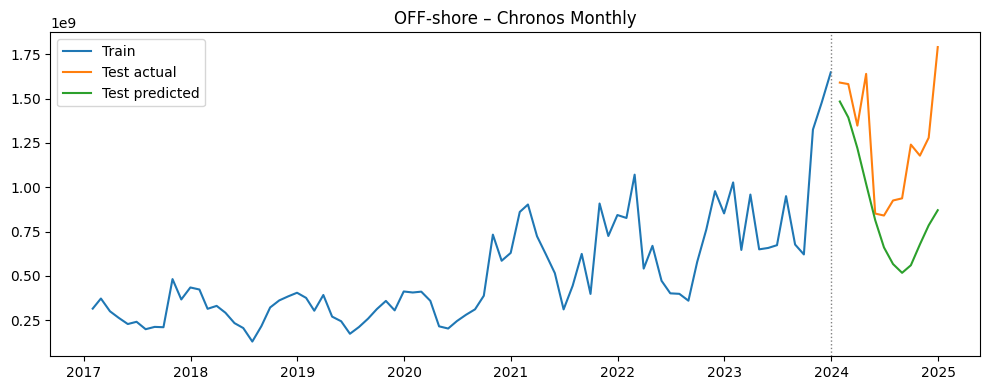

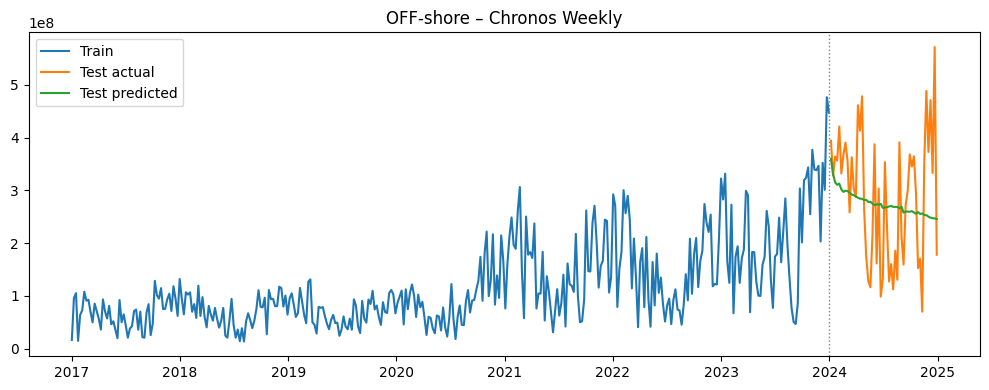

In [25]:
# ================================================================
#  CHRONOS  –  Monthly / Weekly
# ================================================================
import pandas as pd, numpy as np, torch, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from chronos import ChronosPipeline

DATA_PATH = "/Users/polina/Watts-next/data/final_offshore_data_2017_2025.csv"
SITE      = "OFF‑shore"

# 1) LOAD & PREP -------------------------------------------------------
df = pd.read_csv(DATA_PATH)
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"] = df["hour_str"].astype(int) - 1
df["ds"]   = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
df["y"]    = df["volume"]
df = df.sort_values("ds").set_index("ds")

# 2) AGGREGATES --------------------------------------------------------
df_M = df.resample("M")["y"].sum().reset_index()
df_W = df.resample("W")["y"].sum().reset_index()

# splits
m_tr = df_M[df_M.ds <  "2024-01-01"]; m_te = df_M[(df_M.ds >= "2024-01-01") & (df_M.ds < "2025-01-01")]
w_tr = df_W[df_W.ds <  "2024-01-01"]; w_te = df_W[(df_W.ds >= "2024-01-01") & (df_W.ds < "2025-01-01")]

# 3) Chronos pipeline --------------------------------------------------
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", device_map="cpu", torch_dtype=torch.float32)

def chronos_fc(series, horizon):
    ctx = torch.tensor(series, dtype=torch.float32)
    _, mp = pipeline.predict_quantiles(ctx, horizon, [0.5], limit_prediction_length=False)
    preds = mp[0]
    return preds.detach().cpu().numpy() if preds.ndim==1 else preds.mean(dim=0).detach().cpu().numpy()

# MONTHLY
fc_M = chronos_fc(m_tr["y"].values, len(m_te))
mseM  = mean_squared_error(m_te["y"], fc_M); rmseM=np.sqrt(mseM)
maeM  = mean_absolute_error(m_te["y"], fc_M)
r2M   = r2_score(m_te["y"], fc_M)
mapeM = np.mean(np.abs((m_te["y"]-fc_M)/(m_te["y"]+1e-9)))*100

# WEEKLY
fc_W = chronos_fc(w_tr["y"].values, len(w_te))
mseW  = mean_squared_error(w_te["y"], fc_W); rmseW=np.sqrt(mseW)
maeW  = mean_absolute_error(w_te["y"], fc_W)
r2W   = r2_score(w_te["y"], fc_W)
mapeW = np.mean(np.abs((w_te["y"]-fc_W)/(w_te["y"]+1e-9)))*100

print("\n=== CHRONOS –",SITE,"TEST METRICS ===")
print(f"Monthly  MSE={mseM:,.2f}  RMSE={rmseM:,.2f}  MAE={maeM:,.2f}  R²={r2M:.4f}  MAPE={mapeM:,.2f}%")
print(f"Weekly   MSE={mseW:,.2f}  RMSE={rmseW:,.2f}  MAE={maeW:,.2f}  R²={r2W:.4f}  MAPE={mapeW:,.2f}%")

# 4) PLOTS -------------------------------------------------------------
def plot_one(tr, te, fc, title):
    plt.figure(figsize=(10,4))
    plt.plot(tr["ds"], tr["y"], label="Train")
    plt.plot(te["ds"], te["y"], label="Test actual")
    plt.plot(te["ds"], fc,      label="Test predicted")
    plt.axvline(pd.to_datetime("2024-01-01"), ls=":", lw=1, c="gray")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_one(m_tr, m_te, fc_M, f"{SITE} – Chronos Monthly")
plot_one(w_tr, w_te, fc_W, f"{SITE} – Chronos Weekly")
# ================================================================


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_80209/4256103344.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"]   = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_80209/4256103344.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_M = df.resample("M")["y"].sum().reset_index()



=== CHRONOS – ON‑shore TEST METRICS ===
Monthly  MSE=97,351,859,034,914,816.00  RMSE=312,012,594.35  MAE=242,364,720.00  R²=0.1937  MAPE=16.44%
Weekly   MSE=14,890,563,568,402,432.00  RMSE=122,026,896.91  MAE=99,232,728.00  R²=0.1171  MAPE=40.53%


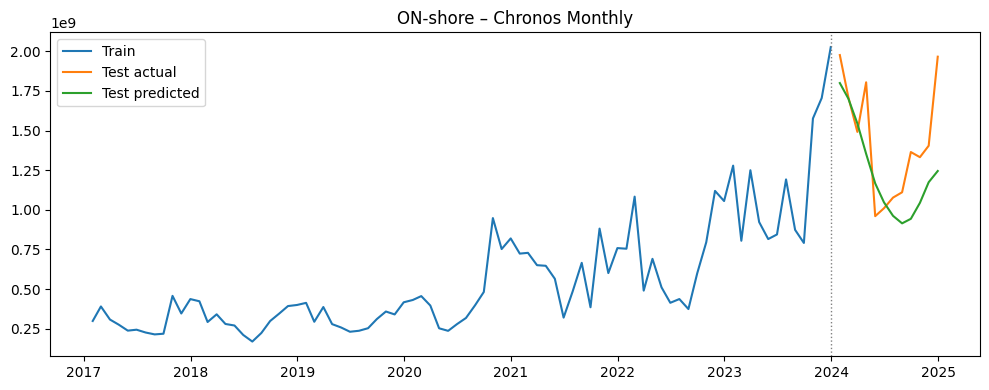

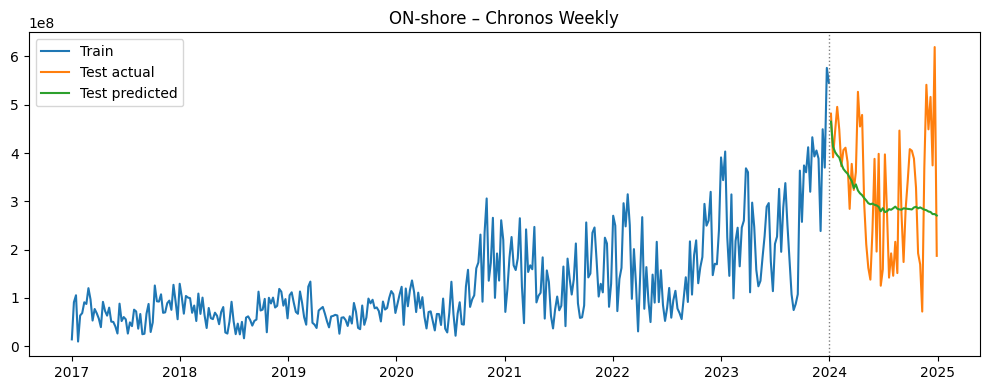

In [26]:
# ================================================================
#  CHRONOS  –  Monthly / Weekly
# ================================================================
import pandas as pd, numpy as np, torch, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from chronos import ChronosPipeline

DATA_PATH = "/Users/polina/Watts-next/data/final_onshore_data_2017_2025.csv" 
SITE      = "ON‑shore"

# 1) LOAD & PREP -------------------------------------------------------
df = pd.read_csv(DATA_PATH)
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"] = df["hour_str"].astype(int) - 1
df["ds"]   = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
df["y"]    = df["volume"]
df = df.sort_values("ds").set_index("ds")

# 2) AGGREGATES --------------------------------------------------------
df_M = df.resample("M")["y"].sum().reset_index()
df_W = df.resample("W")["y"].sum().reset_index()

# splits
m_tr = df_M[df_M.ds <  "2024-01-01"]; m_te = df_M[(df_M.ds >= "2024-01-01") & (df_M.ds < "2025-01-01")]
w_tr = df_W[df_W.ds <  "2024-01-01"]; w_te = df_W[(df_W.ds >= "2024-01-01") & (df_W.ds < "2025-01-01")]

# 3) Chronos pipeline --------------------------------------------------
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", device_map="cpu", torch_dtype=torch.float32)

def chronos_fc(series, horizon):
    ctx = torch.tensor(series, dtype=torch.float32)
    _, mp = pipeline.predict_quantiles(ctx, horizon, [0.5], limit_prediction_length=False)
    preds = mp[0]
    return preds.detach().cpu().numpy() if preds.ndim==1 else preds.mean(dim=0).detach().cpu().numpy()

# MONTHLY
fc_M = chronos_fc(m_tr["y"].values, len(m_te))
mseM  = mean_squared_error(m_te["y"], fc_M); rmseM=np.sqrt(mseM)
maeM  = mean_absolute_error(m_te["y"], fc_M)
r2M   = r2_score(m_te["y"], fc_M)
mapeM = np.mean(np.abs((m_te["y"]-fc_M)/(m_te["y"]+1e-9)))*100

# WEEKLY
fc_W = chronos_fc(w_tr["y"].values, len(w_te))
mseW  = mean_squared_error(w_te["y"], fc_W); rmseW=np.sqrt(mseW)
maeW  = mean_absolute_error(w_te["y"], fc_W)
r2W   = r2_score(w_te["y"], fc_W)
mapeW = np.mean(np.abs((w_te["y"]-fc_W)/(w_te["y"]+1e-9)))*100

print("\n=== CHRONOS –",SITE,"TEST METRICS ===")
print(f"Monthly  MSE={mseM:,.2f}  RMSE={rmseM:,.2f}  MAE={maeM:,.2f}  R²={r2M:.4f}  MAPE={mapeM:,.2f}%")
print(f"Weekly   MSE={mseW:,.2f}  RMSE={rmseW:,.2f}  MAE={maeW:,.2f}  R²={r2W:.4f}  MAPE={mapeW:,.2f}%")

# 4) PLOTS -------------------------------------------------------------
def plot_one(tr, te, fc, title):
    plt.figure(figsize=(10,4))
    plt.plot(tr["ds"], tr["y"], label="Train")
    plt.plot(te["ds"], te["y"], label="Test actual")
    plt.plot(te["ds"], fc,      label="Test predicted")
    plt.axvline(pd.to_datetime("2024-01-01"), ls=":", lw=1, c="gray")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_one(m_tr, m_te, fc_M, f"{SITE} – Chronos Monthly")
plot_one(w_tr, w_te, fc_W, f"{SITE} – Chronos Weekly")
# ================================================================
